In [ ]:
!pip install ruptures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
import seaborn as sns

C:\Users\admin\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
studentVle=pd.read_csv("studentVle.csv")
studentRegistration=pd.read_csv("studentRegistration.csv")
studentInfo=pd.read_csv("studentInfo.csv")
vle=pd.read_csv("vle.csv")
courses=pd.read_csv("courses.csv")

In [3]:
tıklamalar = studentVle.groupby(
    ["code_module", "id_student", "code_presentation", "date", "id_site"]
)["sum_click"].sum().reset_index()

student_kesit = studentInfo[['id_student', 'code_module',"code_presentation", 'final_result']]

In [4]:
# Eğer tıklamalar df'inde code_presentation da varsa bu yolu tercih et:
tıklamalar_final_resultli = pd.merge(
    tıklamalar, 
    student_kesit, 
    on=['id_student', 'code_module', 'code_presentation'], 
    how='left'
)

In [5]:
tıklamalar_nihai_version=pd.merge(
    tıklamalar_final_resultli,
    studentRegistration[["id_student","code_module","code_presentation","date_unregistration"]],
    on=["id_student","code_module","code_presentation"],
    how="left"
)

In [6]:
tıklamalar_nihai_version[
    tıklamalar_nihai_version["date_unregistration"].notna()
]

,code_module,id_student,code_presentation,date,id_site,sum_click,final_result,date_unregistration
2331,AAA,30268,2013J,-10,546614,3,Withdrawn,12.0
2332,AAA,30268,2013J,-10,546652,5,Withdrawn,12.0
2333,AAA,30268,2013J,-10,546662,2,Withdrawn,12.0
2334,AAA,30268,2013J,-9,546614,1,Withdrawn,12.0
2335,AAA,30268,2013J,-8,546614,1,Withdrawn,12.0
...,...,...,...,...,...,...,...,...
8458713,GGG,2679821,2014J,73,897151,2,Withdrawn,101.0
8458714,GGG,2679821,2014J,97,896938,2,Withdrawn,101.0
8458715,GGG,2679821,2014J,97,896943,4,Withdrawn,101.0
8458716,GGG,2679821,2014J,100,896938,1,Withdrawn,101.0


In [7]:
cekilenler=tıklamalar_nihai_version[tıklamalar_nihai_version["final_result"]=="Withdrawn"]

-----------------------------------

# Veri setini hazırlamak

In [8]:
# Bırakma gününden geriye doğru kaçıncı günde olduğunu buluyoruz
#t hesaplama
cekilenler["t"]=cekilenler["date_unregistration"]- cekilenler["date"]

Burada bilgisayar satır satır dönüp if kontrolü yapmaz. Tüm t sütununa yukarıdan aşağıya tek bir saniyede bakar. Şartı sağlayan satırlara True, sağlamayanlara False damgası yapıştırır.

Arkasından cekilenler[kosul] yazdığında, Pandas sadece True damgalı satırları tutar, False olanları tek hamlede siler. DataFrame dünyasında koşul mekanizması tamamen bu "damgalama ve süzme" mantığı üzerine kuruludur.

In [9]:
# ADIM 2: Son 60 Günü Filtreleme (Koşul Sistemi)
# t=0 (bıraktığı gün) ile t=60 (60 gün öncesi) arasını maskeliyoruz
kosul=(cekilenler["t"]>=0)& (cekilenler["t"]<=60)
filtreli_df=cekilenler[kosul].copy()

In [10]:
filtreli_df["t"]=filtreli_df["t"].astype(int)

In [11]:
# ADIM 3: Aynı Gündeki Tıklamaları Toplama
# Öğrenci o gün birden fazla linke tıklamış olabilir, günlük toplamı alıyoruz
grup_df=filtreli_df.groupby(["id_student","code_module","code_presentation","t"])["sum_click"].sum().reset_index()

In [12]:
# ADIM 4: Tıklama Olmayan Boş Günleri Yaratma ve 0 Yazma (Matris Sihri)
# Her öğrenciye t=0'dan t=60'a kadar KESİNLİKLE 61 satır açıyoruz

pivot_df=grup_df.pivot(index=["id_student","code_module","code_presentation"],columns="t",values="sum_click")

In [13]:
# 1. ÖNCE: Tabloda zaten var olan tüm NaN'ları 0 ile dolduruyoruz (Senin yakaladığın yer!)
pivot_df = pivot_df.fillna(0)
# 2. SONRA: Olmayan günleri (59 ve 60 gibi) şablona ekleyip onlara da 0 basıyoruz
pivot_df=pivot_df.reindex(columns=range(61),fill_value=0)

In [14]:
yeni_df=pivot_df.stack().reset_index(name="sum_click")
# Önce öğrenciye, sonra t=0, t=1, t=2... diye gitmesi için t'ye göre sıralıyoruz
yeni_df = yeni_df.sort_values(by=['id_student', 'code_module', 'code_presentation', 't']).reset_index(drop=True)

In [15]:
yeni_df

,id_student,code_module,code_presentation,t,sum_click
0,8462,DDD,2013J,0,0.0
1,8462,DDD,2013J,1,1.0
2,8462,DDD,2013J,2,4.0
3,8462,DDD,2013J,3,7.0
4,8462,DDD,2013J,4,0.0
...,...,...,...,...,...
388504,2698535,CCC,2014B,56,0.0
388505,2698535,CCC,2014B,57,0.0
388506,2698535,CCC,2014B,58,0.0
388507,2698535,CCC,2014B,59,0.0


-----------------------------------

## S1 fazı

- İLk ADIM: HAREKETLİ ORTALAMA (SMOOTHING)
- Neden groupby kullanıyoruz? Çünkü Ali'nin 60. günü ile Ayşe'nin 0. gününün
birbirine karışmasını istemiyoruz.
- Her öğrencinin (ve girdiği modülün) verisi
kendi içinde 0'dan 60'a doğru sıralı olarak işlenmeli.



In [16]:
yeni_df["smoothed_click"]= yeni_df.groupby(["id_student","code_module","code_presentation"])["sum_click"].transform(lambda x: x.rolling(window=7,min_periods=1).mean())

In [17]:
# Kırılma noktalarını (bırakmadan kaç gün önce olduğunu) tutacağımız boş liste
break_days_before_dropout = []

# Her bir öğrencinin verisini ayrı ayrı işlemek için groupby üzerinde dönüyoruz
for (student_id, module, presentation), group_data in yeni_df.groupby(['id_student', 'code_module', 'code_presentation']):

    # Öğrencinin zaman serisinin sırasını garantiye alıyoruz (t'ye göre sırala)
    group_data= group_data.sort_values("t")

    # PELT algoritmasının anlayacağı formata (NumPy array) çeviriyoruz
    signal= group_data["smoothed_click"].values

    # Eğer öğrenci 60 gün boyunca SIFIR tık yapmışsa (ölü balık), kırılma aranamaz.
    # Algoritma çökmesin diye bu durumu pas geçiyoruz.
    if np.sum(signal)==0:
        continue

    # PELT (Penalized Exact Linear Time) Modelini Kuruyoruz
    # model="rbf" (Radial Basis Function): Doğrusal olmayan, karmaşık dalgalanmalarda 
    # seviye (mean) değişimlerini en iyi yakalayan çekirdektir (kernel).
    algo= rpt.Pelt(model="rbf").fit(signal)

    # Kırılma noktasını tahmin et (Predict)
    # pen=10 (Ceza Parametresi): Algoritmanın her ufak düşüşe "kırılma" demesini engeller.
    # Bu değer verinin genliğine göre (tıklama sayılarına göre) ayarlanabilir.

    result= algo.predict(pen=10)

    # result listesi genellikle [kırılma_indeksi, serinin_son_indeksi] döner.
    # Biz ilk büyük kırılmayı almak istiyoruz.
    if len(result)>1:# Eğer kırılma bulunduysa (sadece son indeks dönmediyse)
        break_index=result[0]# İlk kırılmanın gerçekleştiği 't' indeksi
    
        # Senin tablonda t=60 bırakma anı olduğu için:
        # Uzaklık = 60 - break_index
        days_before= 60 - break_index
        break_days_before_dropout.append(days_before)

print(f"Toplam analiz edilen kırılma sinyali sayısı: {len(break_days_before_dropout)}")

Toplam analiz edilen kırılma sinyali sayısı: 1209


S1 Sonucu: Öğrenciler dersi bırakmadan ORTALAMA (Medyan) 30.0 gün önce platformdan kopmaktadır.


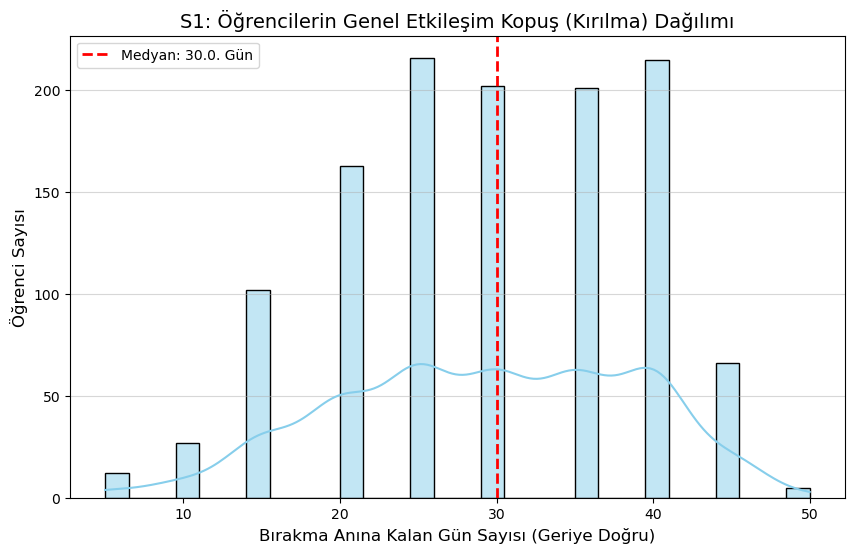

In [18]:
# Listeyi Pandas Serisine çevirelim ki istatistik hesaplamak kolay olsun
result_series= pd.Series(break_days_before_dropout)

# Medyan (Ortanca) değeri bulalım
median_day= result_series.median()
print(f"S1 Sonucu: Öğrenciler dersi bırakmadan ORTALAMA (Medyan) {median_day} gün önce platformdan kopmaktadır.")

plt.figure(figsize=(10,6))
sns.histplot(result_series, bins=30, kde=True,color="skyblue")

plt.axvline(median_day, color="red", linestyle="dashed", linewidth=2, label=f'Medyan: {median_day}. Gün')

plt.title('S1: Öğrencilerin Genel Etkileşim Kopuş (Kırılma) Dağılımı', fontsize=14)
plt.xlabel('Bırakma Anına Kalan Gün Sayısı (Geriye Doğru)', fontsize=12)
plt.ylabel('Öğrenci Sayısı', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

In [19]:
# ── PEN SENSİTİVİTY ANALİZİ ─────────────────────────────────────
sensitivity_sonuclar = []

for pen_val in [5, 10, 15, 20]:
    gecici_days = []
    for (student_id, module, presentation), group_data in yeni_df.groupby(
        ['id_student', 'code_module', 'code_presentation']
    ):
        group_data = group_data.sort_values("t")
        signal = group_data["smoothed_click"].values
        if np.sum(signal) == 0:
            continue
        try:
            algo = rpt.Pelt(model="rbf").fit(signal)
            result = algo.predict(pen=pen_val)
            if len(result) > 1:
                gecici_days.append(60 - result[0])
        except Exception:
            continue

    sensitivity_sonuclar.append({
        "pen"              : pen_val,
        "medyan_gun"       : pd.Series(gecici_days).median(),
        "kirilan_ogrenci_n": len(gecici_days)
    })

sensitivity_df = pd.DataFrame(sensitivity_sonuclar)
print("\n── pen Sensitivity Analizi ──────────────────")
print(sensitivity_df.to_string(index=False))
print("─────────────────────────────────────────────")
print(f"Seçilen değer: pen=10  →  medyan {sensitivity_df.loc[sensitivity_df['pen']==10, 'medyan_gun'].values[0]} gün")


── pen Sensitivity Analizi ──────────────────
 pen  medyan_gun  kirilan_ogrenci_n
   5        35.0               4088
  10        30.0               1209
  15        30.0                162
  20        30.0                 13
─────────────────────────────────────────────
Seçilen değer: pen=10  →  medyan 30.0 gün


In [20]:
# ── SMOOTHING KAYMASI ÖLÇÜMÜ ─────────────────────────────────────
ham_days = []

for (student_id, module, presentation), group_data in yeni_df.groupby(
    ['id_student', 'code_module', 'code_presentation']
):
    group_data = group_data.sort_values("t")
    signal = group_data["sum_click"].values  # smoothed_click değil, HAM sinyal

    if np.sum(signal) == 0:
        continue
    try:
        algo = rpt.Pelt(model="rbf").fit(signal)
        result = algo.predict(pen=10)
        if len(result) > 1:
            ham_days.append(60 - result[0])
    except Exception:
        continue

ham_series = pd.Series(ham_days)
kayma = result_series.median() - ham_series.median()

print("── Smoothing Kayması ────────────────────────────")
print(f"Ham sinyal    →  medyan: {ham_series.median():.1f} gün  (n={len(ham_series)})")
print(f"7g smoothed   →  medyan: {result_series.median():.1f} gün  (n={len(result_series)})")
print(f"Kayma         →  {kayma:+.1f} gün  ({'ileri' if kayma > 0 else 'geri'} kaydırıyor)")
print("─────────────────────────────────────────────────")

── Smoothing Kayması ────────────────────────────
Ham sinyal    →  medyan: 35.0 gün  (n=13)
7g smoothed   →  medyan: 30.0 gün  (n=1209)
Kayma         →  -5.0 gün  (geri kaydırıyor)
─────────────────────────────────────────────────


-----------------------------------

## S2 FAZI

In [21]:
#rı ana kategorilere (örneğin 3 veya 4 makro gruba) dönüştürmeliyiz: mapping
#Böylece activity_category adında yeni bir sütun yaratmış olacağız.

#fillna() normalde eksik (NaN) değerleri doldurmak için kullanılır.
#Ancak biz burada diğer değerler için bir şey atamadığımız için onlar direkt Nan oluyor.
#Biz de Nan ları "diger ile degistirebiliyoz

activity_map = {
    'resource': 'Pasif_Icerik', 'oucontent': 'Pasif_Icerik', 'url': 'Pasif_Icerik', 
    'subpage': 'Pasif_Icerik', 'page': 'Pasif_Icerik', 'homepage': 'Pasif_Icerik', 
    'glossary': 'Pasif_Icerik', 'sharedsubpage': 'Pasif_Icerik', 'folder': 'Pasif_Icerik',
    'forumng': 'Sosyal_Etkilesim', 'oucollaborate': 'Sosyal_Etkilesim', 
    'ouwiki': 'Sosyal_Etkilesim', 'ouilluminate': 'Sosyal_Etkilesim',
    'quiz': 'Olcme_Degerlendirme', 'questionnaire': 'Olcme_Degerlendirme', 
    'externalquiz': 'Olcme_Degerlendirme'
}

#vle tablosunda kategorileri yaratıyoruz
vle["activity_category"] = vle["activity_type"].map(activity_map).fillna("diger")

In [22]:
cekilenler["t"] = cekilenler["date_unregistration"] - cekilenler["date"]
filtreli_df = pd.merge(
    cekilenler,
    vle[['id_site', 'activity_category']],
    on='id_site',
    how='left'
)
filtreli_df = filtreli_df[
    (filtreli_df["t"] >= 0) & (filtreli_df["t"] <= 60)
].copy()

In [23]:
# activity_category bazlı click sayılarının toplamını alıyoruz
agg_df= filtreli_df.groupby(
    ["id_student", "code_module", "code_presentation","t","activity_category"]
)["sum_click"].sum().reset_index()

In [24]:
# Algoritma kesintisiz seri ister. Eğer öğrenci 5. gün hiç forum tıklamadıysa o satır tabloda YOKTUR.
# Pivot Table kullanarak otomatik olarak tüm günleri (0-60) yaratıyor ve olmayan günlere 0 basıyoruz.
grid_df= agg_df.pivot_table(
    index=["id_student","code_module","code_presentation","activity_category"],
    columns="t",
    values="sum_click",
    fill_value=0
)

In [25]:
# Olmayan günleri 0 ile doldurup 0'dan 60'a tam matris yaratıyoruz
grid_df = grid_df.reindex(columns=range(61), fill_value=0).reset_index()

In [26]:
# Pivot edilmiş geniş tabloyu tekrar dikey (zaman serisi) formatına geri döndürüyoruz.
s2_df=grid_df.melt(
    id_vars=['id_student', 'code_module', 'code_presentation', 'activity_category'],
    var_name='t',
    value_name='sum_click'
).sort_values(['id_student', 'code_module', 'code_presentation', 'activity_category', 't'])

In [27]:
# S2 için smoothing motorunu çalıştırıyoruz.
# Bu kez groupby listemize 'activity_category' sütununu da ekledik!

s2_df["smoothed_click"]=s2_df.groupby(
    ['id_student', 'code_module', 'code_presentation', 'activity_category']
)["sum_click"].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

In [28]:
# "diger" kategorisini analizden çıkar (n=14, istatistiksel güç yetersiz)
s2_df = s2_df[s2_df["activity_category"] != "diger"].copy()

In [29]:
s2_results=[]

grouped = s2_df.groupby(['id_student', 'code_module', 'code_presentation', 'activity_category'])

for (student_id, module, presentation, category), group_data in grouped:

    # Zaman sıralamasını garanti ediyoruz
    group_data= group_data.sort_values("t")
    signal= group_data["smoothed_click"].values

    # Eğer öğrenci bu aktivite kategorisini dönem boyunca HİÇ kullanmadıysa analize gerek yoktur.
    if np.sum(signal) == 0:
        continue

    try:

        algo=rpt.Pelt(model="rbf").fit(signal)
        result=algo.predict(pen=10)# Ceza parametresi dengeli tutuldu

        if len(result) >1:
            break_index= result[0]
            days_before=60 -break_index # Bırakma anına geriye doğru kaç gün kaldı?


            # Veritabanı mantığında sözlük yapısı oluşturup listeye ekliyoruz

            s2_results.append({
                            'id_student': student_id,
                            'code_module': module,
                            'code_presentation': presentation,
                            'activity_category': category,
                            'days_before_dropout': days_before
                        })

    except Exception as e:
            # Herhangi bir matematiksel istisnada kodun kırılmaması için blok koruması
            continue

s2_results_df= pd.DataFrame(s2_results)
print(f"Analiz başarıyla bitti. Toplam {len(s2_results_df)} adet spesifik kırılma noktası kaydedildi.")

Analiz başarıyla bitti. Toplam 1913 adet spesifik kırılma noktası kaydedildi.


In [30]:
s2_results_df

,id_student,code_module,code_presentation,activity_category,days_before_dropout
0,30268,AAA,2013J,Pasif_Icerik,40
1,30268,AAA,2013J,Sosyal_Etkilesim,40
2,31269,DDD,2013J,Pasif_Icerik,15
3,31269,DDD,2013J,Sosyal_Etkilesim,25
4,34068,CCC,2014J,Pasif_Icerik,20
...,...,...,...,...,...
1908,2687045,FFF,2013B,Olcme_Degerlendirme,20
1909,2687045,FFF,2013B,Pasif_Icerik,30
1910,2687045,FFF,2013B,Sosyal_Etkilesim,30
1911,2687045,FFF,2013J,Pasif_Icerik,45



--- S2 AKADEMİK KOPUŞ SIRALAMASI ---
  activity_category  median      mean  count
       Pasif_Icerik    30.0 29.627383   1154
   Sosyal_Etkilesim    30.0 28.850671    596
Olcme_Degerlendirme    25.0 24.049080    163
-------------------------------------



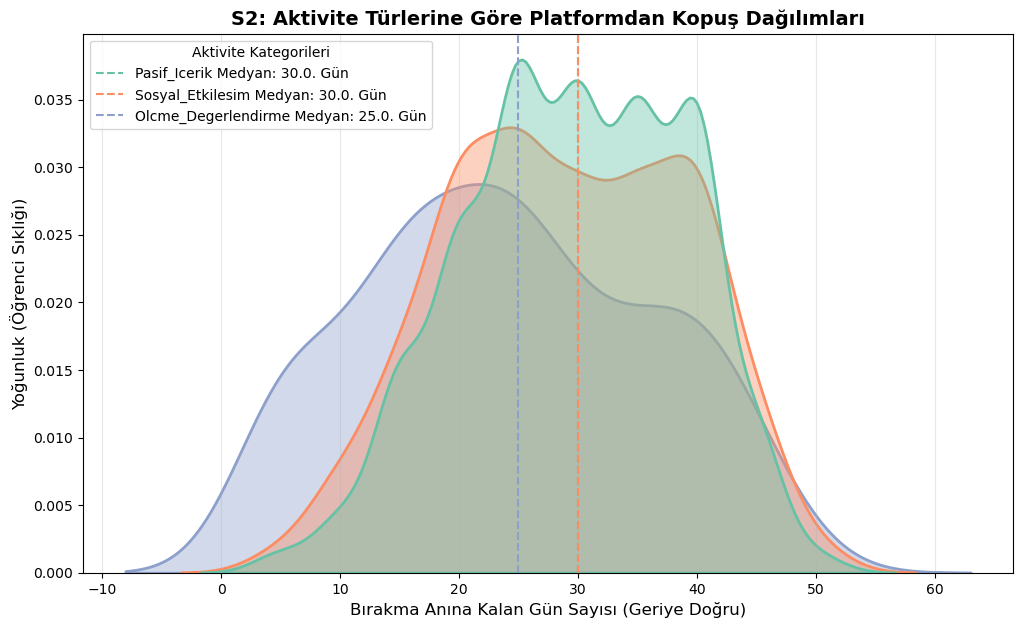

In [31]:
# 1. METRİK: KATEGORİ BAZLI MEDYAN HESAPLAMA
summary_stats = s2_results_df.groupby('activity_category')['days_before_dropout'].agg(['median', 'mean', 'count']).reset_index()
print("\n--- S2 AKADEMİK KOPUŞ SIRALAMASI ---")
print(summary_stats.sort_values(by='median', ascending=False).to_string(index=False))
print("-------------------------------------\n")

# 2. GÖRSELLEŞTİRME: ÇOKLU KDE (KERNEL DENSITY ESTIMATION) GRAFİĞİ
plt.figure(figsize=(12, 7))

# Her bir kategori için yoğunluk eğrisini çiziyoruz
sns.kdeplot(
    data=s2_results_df, 
    x='days_before_dropout', 
    hue='activity_category', 
    fill=True, 
    common_norm=False, 
    palette='Set2', 
    alpha=0.4, 
    linewidth=2
)

plt.title('S2: Aktivite Türlerine Göre Platformdan Kopuş Dağılımları', fontsize=14, fontweight='bold')
plt.xlabel('Bırakma Anına Kalan Gün Sayısı (Geriye Doğru)', fontsize=12)
plt.ylabel('Yoğunluk (Öğrenci Sıklığı)', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Görsel olarak medyan çizgilerini ekleyelim
colors = ['#66c2a5', '#fc8d62', '#8da0cb'] # Set2 palet renkleri
for i, cat in enumerate(s2_results_df['activity_category'].unique()):
    cat_median = s2_results_df[s2_results_df['activity_category'] == cat]['days_before_dropout'].median()
    plt.axvline(cat_median, color=colors[i % len(colors)], linestyle='--', linewidth=1.5, 
                label=f'{cat} Medyan: {cat_median}. Gün')

plt.legend(title="Aktivite Kategorileri")
plt.show()

-----------------------------------

## S3 Fazı

In [32]:
# =====================================================================
# S3 FAZI: KONTROL GRUBU DOĞRULAMASI (BAŞARILI ÖĞRENCİLER ANALİZİ)
# =====================================================================
vle_kopru = vle[['id_site', 'activity_category']]
ham_tıklamalar = pd.merge(studentVle, vle_kopru, on='id_site', how='left')

print("S3 Fazı Başlatılıyor: Kontrol grubu verileri hazırlanıyor...")

# 1. ADIM: Başarılı öğrencileri (Pass & Distinction) seçiyoruz
basarili_ogrenciler = studentInfo[
    studentInfo['final_result'].isin(['Pass', 'Distinction'])
][['id_student', 'code_module', 'code_presentation']]


S3 Fazı Başlatılıyor: Kontrol grubu verileri hazırlanıyor...


In [33]:
# 2. ADIM: Her ders/dönem bazında, bırakanların medyan bırakma gününü (Zaman Çapasını) buluyoruz
medyan_birakma_gunleri = studentRegistration[
    studentRegistration['date_unregistration'].notna()
].merge(
    studentInfo[studentInfo['final_result'] == 'Withdrawn'], 
    on=['id_student', 'code_module', 'code_presentation']
).groupby(['code_module', 'code_presentation'])['date_unregistration'].median().reset_index()

medyan_birakma_gunleri.rename(columns={'date_unregistration': 'dummy_date_unregistration'}, inplace=True)

In [34]:
# 3. ADIM: Başarılı öğrencilere bu yapay bırakma günlerini atıyoruz
hedef_kitle_kontrol = pd.merge(basarili_ogrenciler, medyan_birakma_gunleri, on=['code_module', 'code_presentation'], how='inner')

# Öğrencinin kayıt tarihini getir
kayit_tarihleri = studentRegistration[[
    "id_student", "code_module", "code_presentation", "date_registration"
]]
hedef_kitle_kontrol = pd.merge(
    hedef_kitle_kontrol, kayit_tarihleri,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

# Yapay tarih, öğrencinin kayıt tarihinden önceye denk geliyorsa çıkar
onceki_n = len(hedef_kitle_kontrol)
hedef_kitle_kontrol = hedef_kitle_kontrol[
    hedef_kitle_kontrol["dummy_date_unregistration"] >= hedef_kitle_kontrol["date_registration"]
].copy()

cikarilan = onceki_n - len(hedef_kitle_kontrol)
print(f"Geçerlilik filtresi: {cikarilan} öğrenci çıkarıldı "
      f"(henüz kayıtlı değildi). Kalan: {len(hedef_kitle_kontrol)}")

# 4. ADIM: Ham tıklama tablosundan sadece başarılı kontrol grubunu süzüyoruz
cekilenler_kontrol = pd.merge(ham_tıklamalar, hedef_kitle_kontrol, on=['id_student', 'code_module', 'code_presentation'], how='inner')

Geçerlilik filtresi: 36 öğrenci çıkarıldı (henüz kayıtlı değildi). Kalan: 15349


In [35]:
# 5. ADIM: t Zamanını Hesaplama ve Son 60 Günü Filtreleme
cekilenler_kontrol["t"] = cekilenler_kontrol["dummy_date_unregistration"] - cekilenler_kontrol["date"]

kosul_kontrol = (cekilenler_kontrol["t"] >= 0) & (cekilenler_kontrol["t"] <= 60)
filtreli_kontrol_df = cekilenler_kontrol[kosul_kontrol].copy()
filtreli_kontrol_df["t"] = filtreli_kontrol_df["t"].astype(int)

In [36]:
# 6. ADIM: Günlük ve Kategori Bazlı Toplama
agg_kontrol = filtreli_kontrol_df.groupby(
    ["id_student", "code_module", "code_presentation", "t", "activity_category"]
)["sum_click"].sum().reset_index()


In [37]:
agg_kontrol

,id_student,code_module,code_presentation,t,activity_category,sum_click
0,6516,AAA,2014J,0,Pasif_Icerik,2
1,6516,AAA,2014J,0,Sosyal_Etkilesim,1
2,6516,AAA,2014J,1,Pasif_Icerik,47
3,6516,AAA,2014J,2,Pasif_Icerik,1
4,6516,AAA,2014J,2,Sosyal_Etkilesim,2
...,...,...,...,...,...,...
479109,2698588,BBB,2014J,1,Pasif_Icerik,18
479110,2698588,BBB,2014J,1,Sosyal_Etkilesim,1
479111,2698588,BBB,2014J,3,Pasif_Icerik,10
479112,2698588,BBB,2014J,6,Pasif_Icerik,8


In [38]:
# 7. ADIM: Kesintisiz 61 Günlük Matris Sihri (Eksik günleri 0 yapma)
grid_kontrol = agg_kontrol.pivot_table(
    index=["id_student", "code_module", "code_presentation", "activity_category"],
    columns="t",
    values="sum_click",
    fill_value=0
)
grid_kontrol = grid_kontrol.reindex(columns=range(61), fill_value=0).reset_index()

s3_df = grid_kontrol.melt(
    id_vars=['id_student', 'code_module', 'code_presentation', 'activity_category'],
    var_name='t',
    value_name='sum_click'
).sort_values(['id_student', 'code_module', 'code_presentation', 'activity_category', 't'])


In [39]:
# 8. ADIM: Hareketli Ortalama (Smoothing)
s3_df["smoothed_click"] = s3_df.groupby(
    ['id_student', 'code_module', 'code_presentation', 'activity_category']
)["sum_click"].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

In [40]:
s3_df = s3_df[s3_df["activity_category"] != "diger"].copy()

In [41]:
# 9. ADIM: Kontrol Grubu İçin PELT Algoritmasını Çalıştırma
s3_results = []
grouped_kontrol = s3_df.groupby(['id_student', 'code_module', 'code_presentation', 'activity_category'])

print("Kontrol grubu için PELT kırılma noktaları aranıyor (Bu işlem biraz zaman alabilir)...")

for (student_id, module, presentation, category), group_data in grouped_kontrol:
    group_data = group_data.sort_values("t")
    signal = group_data["smoothed_click"].values

    if np.sum(signal) == 0:
        continue

    try:
        algo = rpt.Pelt(model="rbf").fit(signal)
        result = algo.predict(pen=10)

        if len(result) > 1:
            break_index = result[0]
            days_before = 60 - break_index

            s3_results.append({
                'id_student': student_id,
                'code_module': module,
                'code_presentation': presentation,
                'activity_category': category,
                'days_before_dropout': days_before
            })
    except Exception as e:
        continue

s3_results_df = pd.DataFrame(s3_results)

Kontrol grubu için PELT kırılma noktaları aranıyor (Bu işlem biraz zaman alabilir)...



--- S3 KONTROL GRUBU KOPUŞ SIRALAMASI ---
  activity_category  median      mean  count
Olcme_Degerlendirme    35.0 34.001996    501
   Sosyal_Etkilesim    35.0 32.956905   3179
       Pasif_Icerik    30.0 31.808694   4072
-----------------------------------------



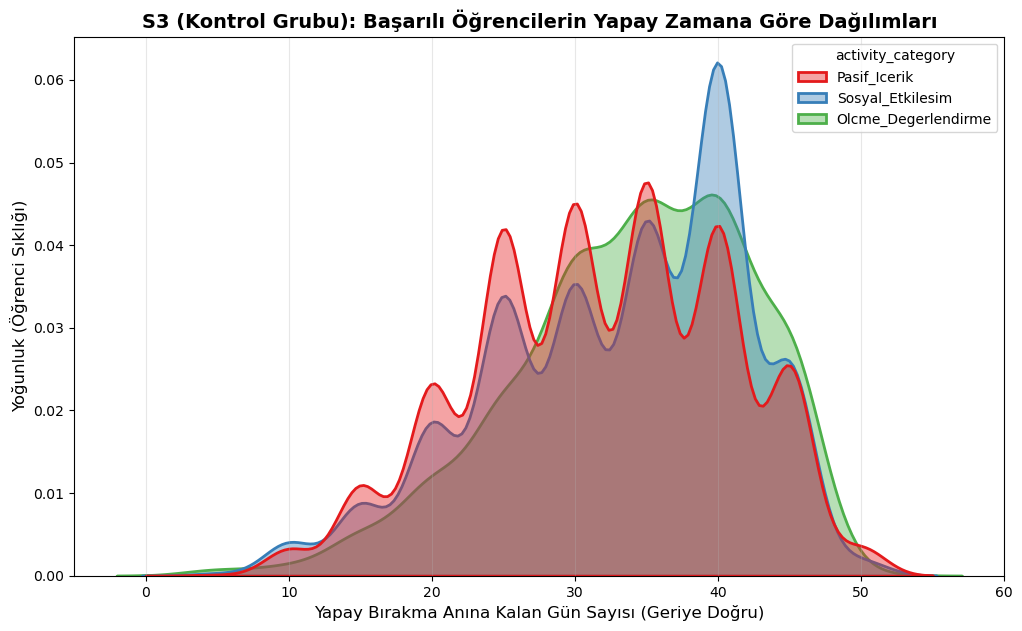

In [42]:
# 10. ADIM: KONTROL GRUBU GÖRSELLEŞTİRME
if len(s3_results_df) > 0:
    summary_stats_s3 = s3_results_df.groupby('activity_category')['days_before_dropout'].agg(['median', 'mean', 'count']).reset_index()
    print("\n--- S3 KONTROL GRUBU KOPUŞ SIRALAMASI ---")
    print(summary_stats_s3.sort_values(by='median', ascending=False).to_string(index=False))
    print("-----------------------------------------\n")

    plt.figure(figsize=(12, 7))
    sns.kdeplot(
        data=s3_results_df, 
        x='days_before_dropout', 
        hue='activity_category', 
        fill=True, 
        common_norm=False, 
        palette='Set1', # Farkı anlamak için bu kez Set1 paletini kullandık
        alpha=0.4, 
        linewidth=2
    )

    plt.title('S3 (Kontrol Grubu): Başarılı Öğrencilerin Yapay Zamana Göre Dağılımları', fontsize=14, fontweight='bold')
    plt.xlabel('Yapay Bırakma Anına Kalan Gün Sayısı (Geriye Doğru)', fontsize=12)
    plt.ylabel('Yoğunluk (Öğrenci Sıklığı)', fontsize=12)
    plt.grid(axis='x', alpha=0.3)

    plt.show()
else:
    print("Kontrol grubunda anlamlı hiçbir kırılma noktası bulunamadı! (Bu hipotezimiz için harika bir haber olurdu!)")

In [43]:
from scipy import stats
import numpy as np

# ── VERİ HAZIRLIĞI ──────────────────────────────────────────────
# Sadece Olcme_Degerlendirme kategorisini her iki gruptan alıyoruz
birakanlar = s2_results_df[
    s2_results_df["activity_category"] == "Olcme_Degerlendirme"
]["days_before_dropout"]

kontrol = s3_results_df[
    s3_results_df["activity_category"] == "Olcme_Degerlendirme"
]["days_before_dropout"]

# ── MANN-WHITNEY U TESTİ (Wilcoxon rank-sum) ────────────────────
# İki bağımsız grup karşılaştırması için doğru test bu.
# Wilcoxon signed-rank ise eşleştirilmiş gruplar içindir (bizimki değil).
stat, p_value = stats.mannwhitneyu(birakanlar, kontrol, alternative="less")
# alternative="less": bırakanların daha küçük değerlere sahip olduğunu test ediyoruz
# yani "bırakanlar daha erken kopuyor" yönlü hipotez

# ── EFFECT SIZE: Rank-Biserial Correlation ───────────────────────
# r = 1 - (2U / n1*n2)   → -1 ile 1 arasında
# |r| < 0.3 küçük, 0.3-0.5 orta, > 0.5 büyük etki
n1 = len(birakanlar)
n2 = len(kontrol)
effect_size = 1 - (2 * stat) / (n1 * n2)

# ── SONUÇLAR ────────────────────────────────────────────────────
print("=" * 50)
print("   İSTATİSTİKSEL TEST SONUÇLARI")
print("=" * 50)
print(f"Grup 1 — Bırakanlar     : n={n1}, medyan={birakanlar.median():.1f} gün")
print(f"Grup 2 — Kontrol Grubu  : n={n2}, medyan={kontrol.median():.1f} gün")
print("-" * 50)
print(f"Mann-Whitney U istatistiği : {stat:.1f}")
print(f"p-değeri                   : {p_value:.4f}")
print(f"Effect Size (rank-biserial): {effect_size:.3f}")
print("-" * 50)

# p yorumu
if p_value < 0.001:
    p_yorum = "p < 0.001 → Son derece anlamlı"
elif p_value < 0.01:
    p_yorum = "p < 0.01  → Çok anlamlı"
elif p_value < 0.05:
    p_yorum = "p < 0.05  → Anlamlı"
else:
    p_yorum = "p >= 0.05 → Anlamlı değil"

# effect size yorumu
abs_r = abs(effect_size)
if abs_r >= 0.5:
    r_yorum = "Büyük etki"
elif abs_r >= 0.3:
    r_yorum = "Orta etki"
else:
    r_yorum = "Küçük etki"

print(f"p Yorumu       : {p_yorum}")
print(f"Effect Size    : {r_yorum} (|r| = {abs_r:.3f})")
print("=" * 50)

   İSTATİSTİKSEL TEST SONUÇLARI
Grup 1 — Bırakanlar     : n=163, medyan=25.0 gün
Grup 2 — Kontrol Grubu  : n=501, medyan=35.0 gün
--------------------------------------------------
Mann-Whitney U istatistiği : 21162.0
p-değeri                   : 0.0000
Effect Size (rank-biserial): 0.482
--------------------------------------------------
p Yorumu       : p < 0.001 → Son derece anlamlı
Effect Size    : Orta etki (|r| = 0.482)


In [44]:
from scipy import stats
import pandas as pd
from statsmodels.stats.multitest import multipletests


def wilcoxon_test(modul, s2_results_df, s3_results_df, kategori="Olcme_Degerlendirme"):
    # O modüle ve kategoriye ait verileri filtrele
    birakanlar = s2_results_df[
        (s2_results_df["code_module"] == modul) &
        (s2_results_df["activity_category"] == kategori)
    ]["days_before_dropout"]

    kontrol = s3_results_df[
        (s3_results_df["code_module"] == modul) &
        (s3_results_df["activity_category"] == kategori)
    ]["days_before_dropout"]

    # Yeterli veri yoksa atla (güvenilir test için en az 10 gözlem)
    if len(birakanlar) < 10 or len(kontrol) < 10:
        return None

    stat, p = stats.mannwhitneyu(birakanlar, kontrol, alternative="less")
    effect_size = 1 - (2 * stat) / (len(birakanlar) * len(kontrol))

    return {
        "code_module"     : modul,
        "birakan_n"       : len(birakanlar),
        "birakan_medyan"  : birakanlar.median(),
        "kontrol_n"       : len(kontrol),
        "kontrol_medyan"  : kontrol.median(),
        "fark_gun"        : kontrol.median() - birakanlar.median(),
        "p_degeri"        : round(p, 4),
        "effect_size"     : round(effect_size, 3),
        "anlamlilik"      : "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    }

# Tüm modüller üzerinde dön
sonuclar = []
for modul in sorted(s2_results_df["code_module"].unique()):
    sonuc = wilcoxon_test(modul, s2_results_df, s3_results_df)
    if sonuc:
        sonuclar.append(sonuc)

# Sonuçları tabloya çevir, farka göre sırala
modul_df = pd.DataFrame(sonuclar).sort_values("fark_gun", ascending=False)

# Ham p-değerlerini al, BH düzeltmesi uygula
_, p_duzeltilmis, _, _ = multipletests(modul_df["p_degeri"].values, method="fdr_bh")

modul_df["p_duzeltilmis"] = p_duzeltilmis.round(4)
modul_df["anlamlilik_duzeltilmis"] = modul_df["p_duzeltilmis"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
)

# Karşılaştırmalı tablo: ham vs düzeltilmiş
print(modul_df[[
    "code_module", "birakan_n", "fark_gun",
    "p_degeri", "anlamlilik",
    "p_duzeltilmis", "anlamlilik_duzeltilmis"
]].to_string(index=False))

print(modul_df.to_string(index=False))

code_module  birakan_n  fark_gun  p_degeri anlamlilik  p_duzeltilmis anlamlilik_duzeltilmis
        EEE         13      15.0    0.0000        ***         0.0000                    ***
        FFF         47      10.0    0.0000        ***         0.0000                    ***
        CCC         78       5.0    0.0026         **         0.0035                     **
        DDD         14       5.0    0.0273          *         0.0273                      *
code_module  birakan_n  birakan_medyan  kontrol_n  kontrol_medyan  fark_gun  p_degeri  effect_size anlamlilik  p_duzeltilmis anlamlilik_duzeltilmis
        EEE         13            20.0        118            35.0      15.0    0.0000        0.725        ***         0.0000                    ***
        FFF         47            25.0        214            35.0      10.0    0.0000        0.511        ***         0.0000                    ***
        CCC         78            25.0         89            30.0       5.0    0.0026        0.2

In [45]:
vle["code_module"].unique()

<ArrowStringArray>
['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']
Length: 7, dtype: str